# Step 2. 강원도 산불발생 날씨·지수 대조군 재분석

산불 발생과 비발생 비교를 위한 사건, 격자, 누수 방지 기상, 캐나다 지수를 준비한다.

## 현재 구현 범위

이 노트북은 **원천 데이터 경로 확인, 로딩, 필수 스키마 검증, 시간 파싱,
기본 행 수 감사**까지 구현한다. 통계 분석과 시각화는 이후 셀에서 이어서 작성한다.

공통 데이터 계약은 `README.md`를 따른다. Step 2~6에서 캐나다 지수를 사건 시각에
결합할 때는 12시 이전이면 전일 정오, 12시 이후이면 당일 정오 자료만 사용한다.

결과 해석은 이 노트북에 작성하지 않는다. 결과표와 플롯을 함께 검토한 해석,
한계와 다음 코드 반영사항은 대응 `진행예정로그.md`에만 기록한다.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
candidates = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
REPO_ROOT = next(
    (path for path in candidates if (path / "jsw/강원_재_EDA/re_eda_common.py").exists()),
    Path(r"D:/farm-system-public-02"),
)
MODULE_DIR = REPO_ROOT / "jsw/강원_재_EDA"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from re_eda_common import (
    DATA_PATHS,
    DERIVED_WEATHER_COLUMNS,
    RAW_WEATHER_COLUMNS,
    add_canadian_asof_keys,
    check_sources,
    configure_notebook,
    frame_inventory,
    load_access_lines,
    load_canadian_indices,
    load_dem_metadata,
    load_fire,
    load_grid_bundle,
    load_hourly_weather,
    load_infrastructure,
    load_landcover,
    load_roads,
    load_terrain,
)

configure_notebook()

REPO_ROOT: D:\farm-system-public-02
matplotlib font.family: ['Malgun Gothic']


## 1. 원천 파일 존재 여부

In [2]:
SOURCE_KEYS = ['fire', 'weather_cells', 'weather_grid', 'weather_hourly_derived', 'climate_type', 'canada_ffmc', 'canada_fwi']
source_audit = check_sources(SOURCE_KEYS)
display(source_audit)

,데이터키,존재,크기_MB,경로
0,fire,True,0.39,D:\farm-system-public-02\data\강원도_데이터\강원도_산불발생...
1,weather_cells,True,0.05,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
2,weather_grid,True,0.09,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
3,weather_hourly_derived,True,438.45,D:\farm-system-public-02\data\학습데이터\기상_시간단위_파생...
4,climate_type,True,0.00,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
5,canada_ffmc,True,6.75,D:\farm-system-public-02\data\학습데이터\캐나다_FFMC_선...
6,canada_fwi,True,10.10,D:\farm-system-public-02\data\학습데이터\캐나다_FWI_일단...


## 2. 산불 및 기상격자 로딩

In [3]:
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_cells = grid_bundle["cells"]
climate_type = grid_bundle["climate"]
weather_grid = grid_bundle["grid"]

print("산불:", len(fire), "건")
print("좌표 유효 산불:", len(fire_points), "건")
print("발생시각 결측:", int(fire["기준시각"].isna().sum()), "건")
display(fire.head())

산불: 3405 건
좌표 유효 산불: 3405 건
발생시각 결측: 0 건


,fire_id,연도,월,일,시간,진화소요시간(HH),위도,경도,발생지역시도명,발생지역시군구명,발생지역읍면동명,발생지역리명,발생지역번지,발생원인명,피해면적(ha),피해금액,발생일시,기준시각,발생날짜,번지유형
0,F_003556,2020,4,30,18,NaN,37.432421,127.803653,강원특별자치도,원주시,지정면,월송리,산172,NaN,NaN,NaN,2020-04-30 18:00:00,2020-04-30 18:00:00,2020-04-30,임야번지(산)
1,F_006688,2020,4,30,18,NaN,37.432421,127.803653,강원특별자치도,원주시,지정면,월송리,산172,NaN,NaN,NaN,2020-04-30 18:00:00,2020-04-30 18:00:00,2020-04-30,임야번지(산)
2,F_006690,2020,5,1,22,NaN,37.773694,127.446131,강원특별자치도,고성군,토성면,도원리,NaN,NaN,NaN,NaN,2020-05-01 22:00:00,2020-05-01 22:00:00,2020-05-01,일반번지
3,F_007615,2020,1,1,12,NaN,37.761451,128.841125,강원특별자치도,강릉시,성산면,위촌리,877,NaN,NaN,NaN,2020-01-01 12:00:00,2020-01-01 12:00:00,2020-01-01,일반번지
4,F_007616,2020,1,3,12,NaN,37.329735,129.043221,강원특별자치도,삼척시,신기면,대이리,30,NaN,NaN,NaN,2020-01-03 12:00:00,2020-01-03 12:00:00,2020-01-03,일반번지


## 3. 누수 방지 시간기상 파생자료 로딩

In [4]:
hourly_weather = load_hourly_weather(
    derived=True,
    columns=DERIVED_WEATHER_COLUMNS,
)
print("기간:", hourly_weather["일시"].min(), "~", hourly_weather["일시"].max())
print("기상셀 수:", hourly_weather["기상셀ID"].nunique())
display(hourly_weather.head())

기간: 2020-01-01 00:00:00 ~ 2021-12-31 23:00:00
기상셀 수: 92


,기상셀ID,일시,시점_기온_C,시점_풍속_m_s,시점_습도_pct,직전24h_평균풍속,직전24h_최대풍속,직전48h_평균풍속,직전48h_최대풍속,직전24h_평균기온_C,직전24h_평균습도,직전24h_최소습도,직전48h_평균습도,직전48h_최소습도,직전24h_강수량합,직전48h_강수량합,시점_풍향_deg,풍향_sin,풍향_cos,서풍계열_여부,시점_현지기압_hPa,시점_해면기압_hPa,기압변동_3h,D-1_최소습도_pct,D-1_평균습도_pct,D-1_강수량합_mm,D-2_최소습도_pct,D-3_최소습도_pct
0,YD_0001,2020-01-01 00:00:00,-4.18,4.52,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,226.26,-0.722485,-0.691387,1,999.82,1021.12,NaN,NaN,NaN,NaN,NaN,NaN
1,YD_0001,2020-01-01 01:00:00,-3.59,4.28,40.85,4.520,4.52,4.520,4.52,-4.1800,29.0000,29.0,29.0000,29.0,0.0,0.0,235.90,-0.828060,-0.560639,1,999.68,1020.90,NaN,NaN,NaN,NaN,NaN,NaN
2,YD_0001,2020-01-01 02:00:00,-2.97,4.01,44.09,4.400,4.52,4.400,4.52,-3.8850,34.9250,29.0,34.9250,29.0,0.0,0.0,243.05,-0.891402,-0.453213,1,999.70,1020.91,NaN,NaN,NaN,NaN,NaN,NaN
3,YD_0001,2020-01-01 03:00:00,-2.79,4.89,50.15,4.270,4.52,4.270,4.52,-3.5800,37.9800,29.0,37.9800,29.0,0.0,0.0,233.54,-0.804272,-0.594261,1,999.58,1020.75,-0.24,NaN,NaN,NaN,NaN,NaN
4,YD_0001,2020-01-01 04:00:00,-2.54,4.32,52.23,4.425,4.89,4.425,4.89,-3.3825,41.0225,29.0,41.0225,29.0,0.0,0.0,245.21,-0.907851,-0.419294,1,999.42,1020.55,-0.26,NaN,NaN,NaN,NaN,NaN


## 4. 캐나다 지수 및 사건별 as-of 키 준비

In [5]:
canadian_indices = load_canadian_indices()
fire = add_canadian_asof_keys(fire, time_column="기준시각")

asof_violations = (
    fire["캐나다지수_기준시각"] > fire["기준시각"]
).sum()
assert asof_violations == 0
display(
    fire[
        [
            "fire_id",
            "기준시각",
            "캐나다지수_기준날짜",
            "캐나다지수_기준시각",
            "캐나다지수_시차시간",
            "캐나다지수_당일사용여부",
        ]
    ].head()
)

,fire_id,기준시각,캐나다지수_기준날짜,캐나다지수_기준시각,캐나다지수_시차시간,캐나다지수_당일사용여부
0,F_003556,2020-04-30 18:00:00,2020-04-30,2020-04-30 12:00:00,6.0,True
1,F_006688,2020-04-30 18:00:00,2020-04-30,2020-04-30 12:00:00,6.0,True
2,F_006690,2020-05-01 22:00:00,2020-05-01,2020-05-01 12:00:00,10.0,True
3,F_007615,2020-01-01 12:00:00,2020-01-01,2020-01-01 12:00:00,0.0,True
4,F_007616,2020-01-03 12:00:00,2020-01-03,2020-01-03 12:00:00,0.0,True


## 로딩 결과 요약

In [6]:
loaded_frames = {
    "fire": fire,
    "fire_points": fire_points,
    "weather_cells": weather_cells,
    "climate_type": climate_type,
    "weather_grid": weather_grid,
    "hourly_weather": hourly_weather,
    "canadian_indices": canadian_indices,
}
display(frame_inventory(loaded_frames))

,이름,행,열,메모리_MB,CRS
0,fire,3405,25,0.86,NaN
1,fire_points,3405,21,0.78,EPSG:4326
2,weather_cells,92,12,0.05,NaN
3,climate_type,92,3,0.00,NaN
4,weather_grid,92,12,0.01,EPSG:4326
5,hourly_weather,1614048,28,355.57,NaN
6,canadian_indices,67252,16,8.66,NaN


## 5. S2-01 산불-기상셀 공간조인과 미매칭 감사

,총_건수,매칭_건수,미매칭_건수,매칭률_pct
0,3405,3401,4,99.882526


,fire_id,발생일시
2,F_006690,2020-05-01 22:00:00
2064,F_009678,2021-02-03 16:00:00
3051,F_010665,2021-05-11 13:00:00
3190,F_010893,2020-04-16 13:00:00


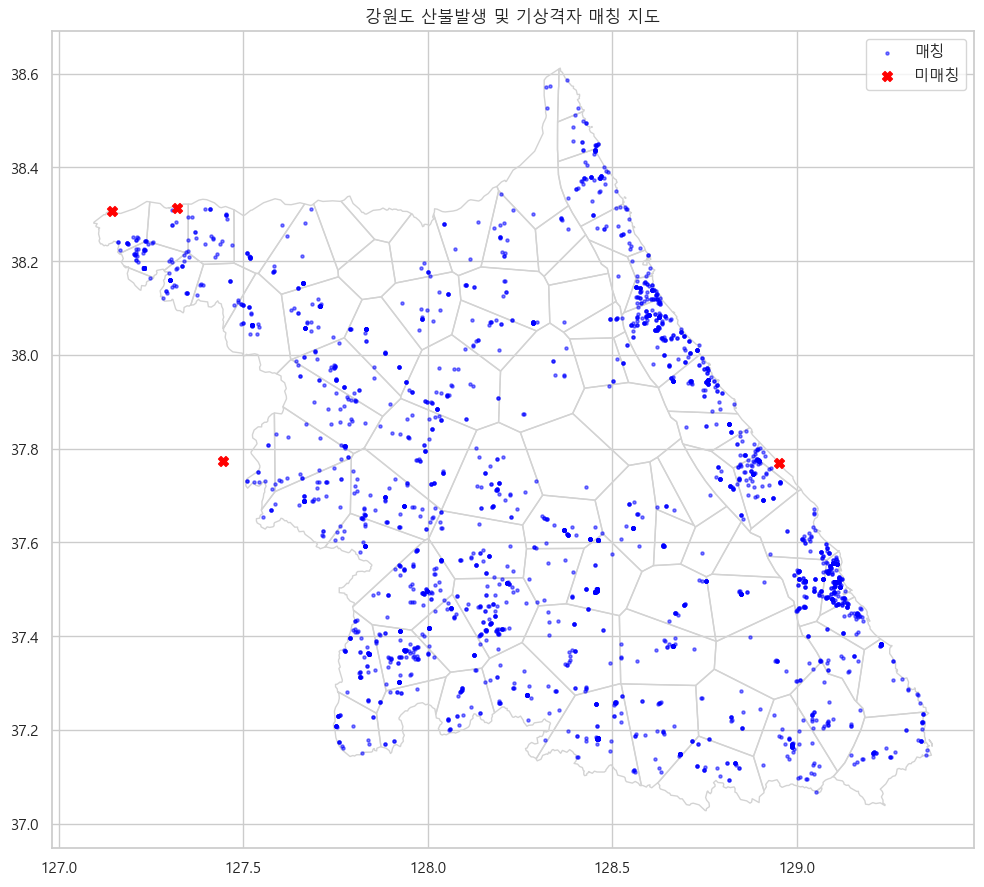

In [7]:

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 좌표계 일치 확인 및 공간조인
if fire_points.crs != weather_grid.crs:
    fire_points = fire_points.to_crs(weather_grid.crs)

fire_joined = gpd.sjoin(fire_points, weather_grid[['기상셀ID', 'geometry']], how="left", predicate="within")

Path("outputs/Step2/tables").mkdir(parents=True, exist_ok=True)
Path("outputs/Step2/plots").mkdir(parents=True, exist_ok=True)

# 1. 매칭률 계산
match_rate = pd.DataFrame({
    '총_건수': [len(fire_joined)],
    '매칭_건수': [fire_joined['기상셀ID'].notna().sum()],
    '미매칭_건수': [fire_joined['기상셀ID'].isna().sum()],
    '매칭률_pct': [fire_joined['기상셀ID'].notna().mean() * 100]
})
display(match_rate)
match_rate.to_csv("outputs/Step2/tables/S2-01_matching_rate.csv", index=False, encoding='utf-8-sig')

# 2. 미매칭 목록
unmatched = fire_joined[fire_joined['기상셀ID'].isna()]
if len(unmatched) > 0:
    display(unmatched[['fire_id', '발생일시']]) # available columns
    unmatched.to_csv("outputs/Step2/tables/S2-01_unmatched_list.csv", index=False, encoding='utf-8-sig')
else:
    pd.DataFrame(columns=['fire_id']).to_csv("outputs/Step2/tables/S2-01_unmatched_list.csv", index=False, encoding='utf-8-sig')

# 3. 매칭 지도 시각화
fig, ax = plt.subplots(figsize=(10, 10))
weather_grid.plot(ax=ax, facecolor="none", edgecolor="lightgray")
fire_joined[fire_joined['기상셀ID'].notna()].plot(ax=ax, color="blue", markersize=5, alpha=0.5, label="매칭")
if len(unmatched) > 0:
    unmatched.plot(ax=ax, color="red", markersize=50, marker='X', label="미매칭")
ax.legend()
ax.set_title("강원도 산불발생 및 기상격자 매칭 지도")
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-01_matching_map.png", dpi=300)
plt.show()


## 6. S2-02 발생 지도와 월별·시간대별 분포

,월,시간,기후지형유형,번지유형,건수,비율_pct
153,2,10,영서 내륙형,일반번지,311,9.144369
169,2,13,영동 해안형,일반번지,171,5.027933
151,2,10,영동 해안형,일반번지,158,4.645692
753,10,15,영서 내륙형,일반번지,100,2.940312
150,2,10,영동 해안형,임야번지(산),68,1.999412


기후지형유형,영동 해안형,영서 내륙형,고지·산간형
월,,,
1,104,66,36
2,682,604,203
3,60,148,30
4,60,218,50
5,27,98,22
6,12,13,3
7,0,3,1
8,0,1,0
9,2,4,1


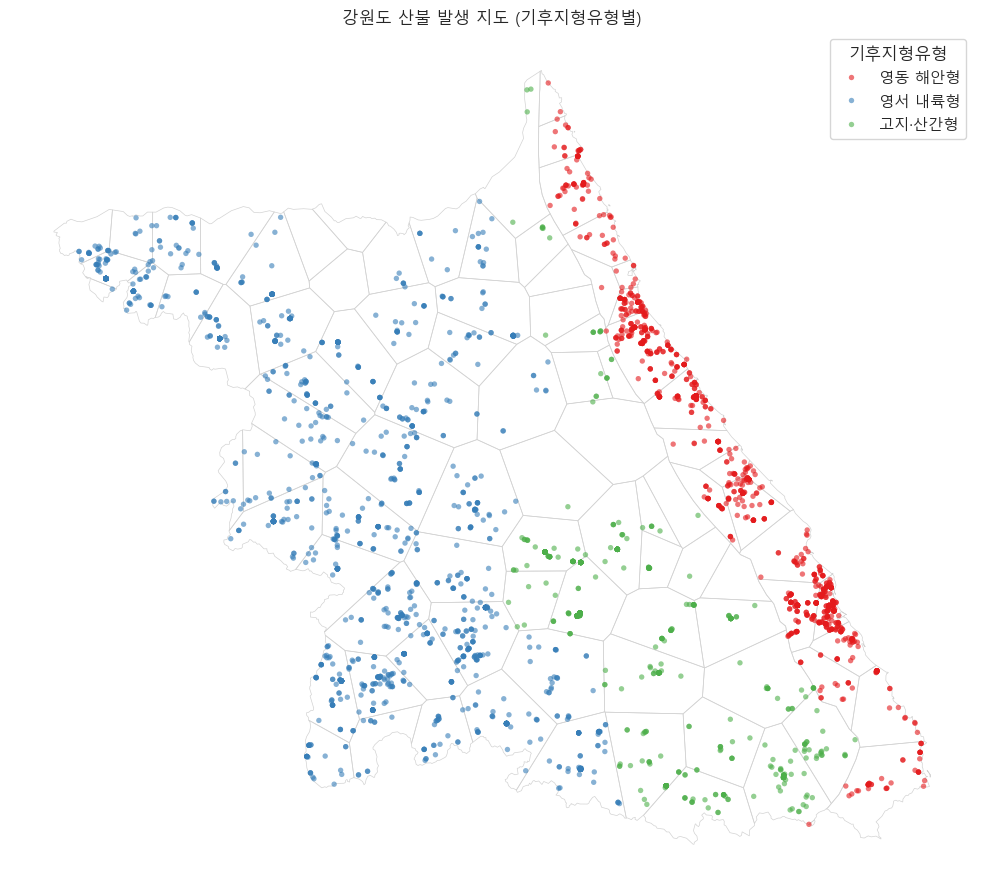

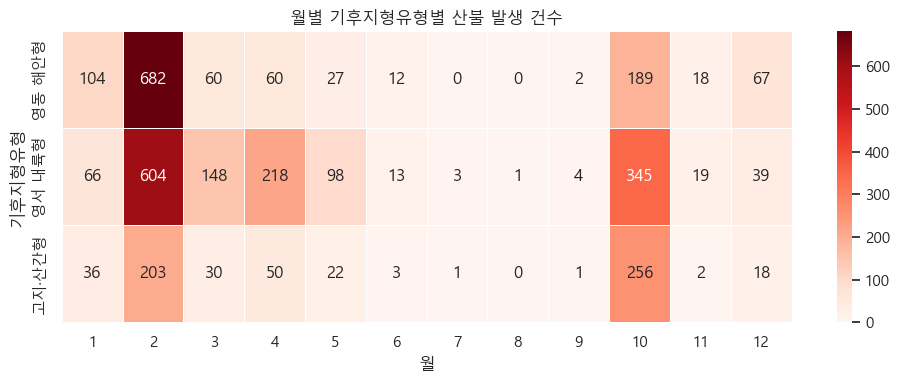

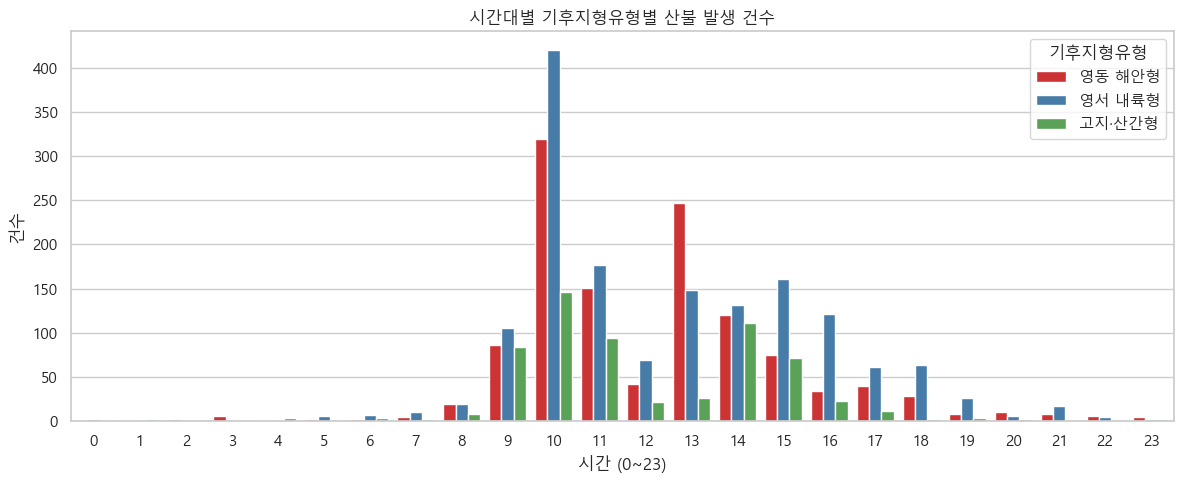

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np

# 1. 매칭된 산불 데이터 필터링 및 기후지형유형 결합
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched = fire_matched.merge(climate_type[['기상셀ID', '기후지형유형']], on='기상셀ID', how='left')

# 범주형 순서 고정
climate_order = ['영동 해안형', '영서 내륙형', '고지·산간형']
fire_matched['기후지형유형'] = pd.Categorical(fire_matched['기후지형유형'], categories=climate_order, ordered=True)

bungi_order = ['임야번지(산)', '일반번지']
fire_matched['번지유형'] = pd.Categorical(fire_matched['번지유형'], categories=bungi_order, ordered=True)

# 2. 결과표 생성 (월, 시간, 유형별 건수)
agg_counts = fire_matched.groupby(['월', '시간', '기후지형유형', '번지유형'], observed=False).size().reset_index(name='건수')
agg_counts = agg_counts[agg_counts['건수'] > 0]
agg_counts['비율_pct'] = (agg_counts['건수'] / len(fire_matched)) * 100

display(agg_counts.sort_values(by='건수', ascending=False).head())
agg_counts.to_csv("outputs/Step2/tables/S2-02_monthly_hourly_type_counts.csv", index=False, encoding='utf-8-sig')

monthly_region = fire_matched.groupby(['월', '기후지형유형'], observed=False).size().unstack(fill_value=0)
display(monthly_region)

# 3. 산불 발생 지도 (권역별 색상)
fig, ax = plt.subplots(figsize=(10, 10))
weather_grid.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.5)
sns.scatterplot(
    data=fire_matched, 
    x=fire_matched.geometry.x, 
    y=fire_matched.geometry.y, 
    hue='기후지형유형', 
    palette='Set1', 
    s=15, 
    alpha=0.6, 
    edgecolor='none',
    ax=ax
)
ax.set_title("강원도 산불 발생 지도 (기후지형유형별)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-02_fire_map.png", dpi=300)
plt.show()

# 4. 월 × 기후지형유형 Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(monthly_region.T, annot=True, fmt='d', cmap='Reds', linewidths=.5)
plt.title("월별 기후지형유형별 산불 발생 건수")
plt.ylabel("기후지형유형")
plt.xlabel("월")
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-02_month_type_heatmap.png", dpi=300)
plt.show()

# 5. 시간대별 분포 Plot
plt.figure(figsize=(12, 5))
sns.countplot(data=fire_matched, x='시간', hue='기후지형유형', palette='Set1')
plt.title("시간대별 기후지형유형별 산불 발생 건수")
plt.xlabel("시간 (0~23)")
plt.ylabel("건수")
plt.legend(title='기후지형유형')
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-02_hourly_plot.png", dpi=300)
plt.show()


## 7. S2-03. 전체 비발생 후보 생성 및 누수·중복 감사

Loading hourly weather data...
전체 시간기상 레코드 수: 1,614,048
제외된 산불 레코드 수: 1,150
전체 비발생 후보 수: 1,612,898


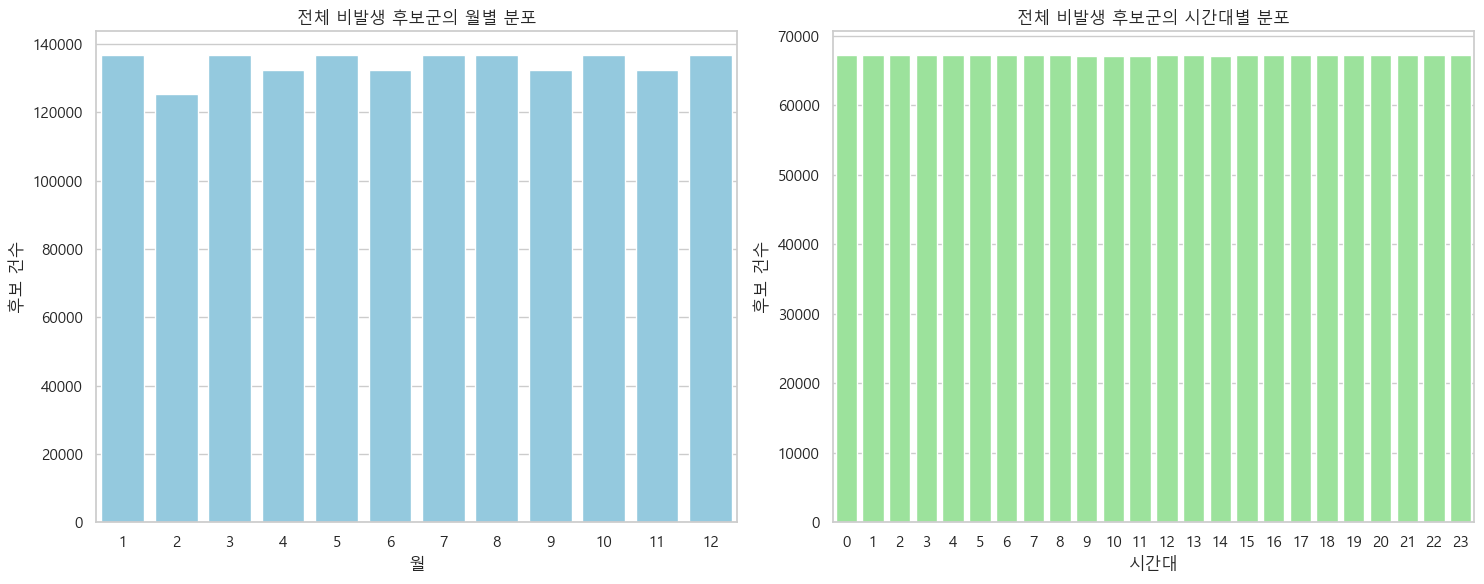

In [9]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from re_eda_common import load_fire, load_grid_bundle, load_hourly_weather

# 1. 데이터 로드
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_grid = grid_bundle["grid"]

# 산불 데이터 공간조인 (S2-01 방식)
fire_joined = gpd.sjoin(fire_points, weather_grid, how='left', predicate='within')
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched['기준시각'] = pd.to_datetime(fire_matched['기준시각'])

# 산불 발생 시공간 튜플 세트 (중복 제거)
fire_events = set(zip(fire_matched['기상셀ID'], fire_matched['기준시각']))

print("Loading hourly weather data...")
hourly_weather = load_hourly_weather(derived=False, columns=['기상셀ID', '일시'])

# 2. 전체 비발생 후보군 분리
hourly_weather['is_fire'] = hourly_weather.apply(lambda row: (row['기상셀ID'], row['일시']) in fire_events, axis=1)

non_fire_candidates = hourly_weather[~hourly_weather['is_fire']].copy()

print(f"전체 시간기상 레코드 수: {len(hourly_weather):,}")
print(f"제외된 산불 레코드 수: {hourly_weather['is_fire'].sum():,}")
print(f"전체 비발생 후보 수: {len(non_fire_candidates):,}")

count_df = pd.DataFrame({
    '구분': ['전체 레코드', '제외 산불', '비발생 후보'],
    '건수': [len(hourly_weather), hourly_weather['is_fire'].sum(), len(non_fire_candidates)]
})
count_df.to_csv("outputs/Step2/tables/S2-03_candidate_counts.csv", index=False, encoding='utf-8-sig')

# 3. 후보군의 월별/시간대별 구성 분포 확인
non_fire_candidates['월'] = non_fire_candidates['일시'].dt.month
non_fire_candidates['시간대'] = non_fire_candidates['일시'].dt.hour

dist_df = non_fire_candidates.groupby(['월', '시간대']).size().reset_index(name='빈도')
dist_df.to_csv("outputs/Step2/tables/S2-03_month_hour_distribution.csv", index=False, encoding='utf-8-sig')

# 4. 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=non_fire_candidates, x='월', ax=axes[0], color='skyblue')
axes[0].set_title('전체 비발생 후보군의 월별 분포')
axes[0].set_ylabel('후보 건수')

sns.countplot(data=non_fire_candidates, x='시간대', ax=axes[1], color='lightgreen')
axes[1].set_title('전체 비발생 후보군의 시간대별 분포')
axes[1].set_ylabel('후보 건수')

plt.tight_layout()
plt.show()

## 8. S2-04. 동일 셀·월·시간대 1:5 매칭 대조군 생성

Loading hourly weather keys...
매칭 대상 산불 건수: 3401 건
1:5 매칭 성공 건수 (5개 모두 찾음): 3401 건 (100.00%)
생성된 총 대조군 레코드 수: 17,005 건
대조군 내 동일 기상레코드 중복 사용 횟수: 6,487 건


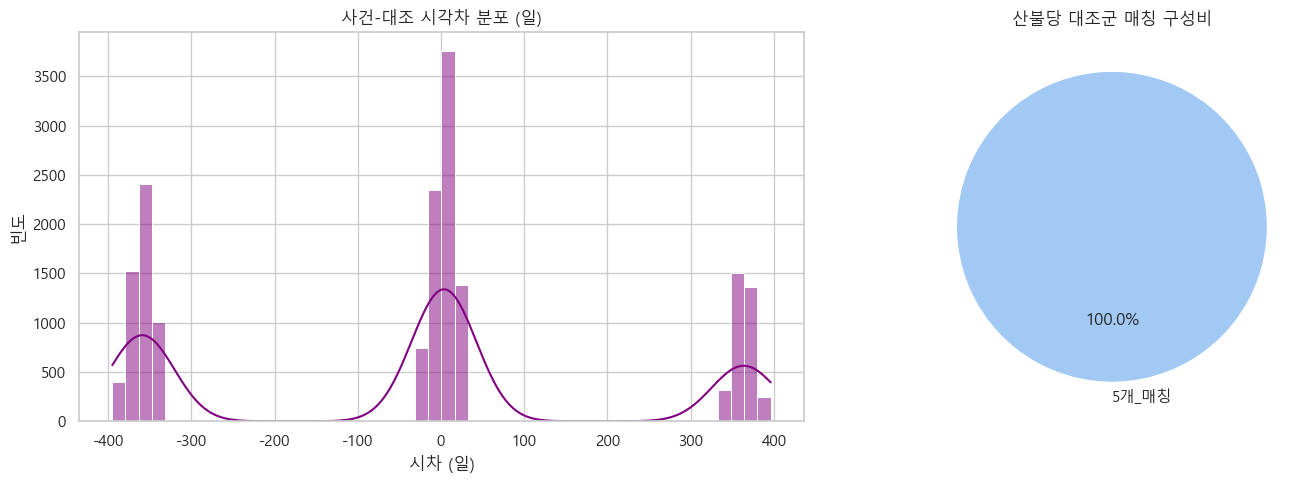

In [10]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from re_eda_common import load_fire, load_grid_bundle, load_hourly_weather

# 1. 산불 및 후보군 데이터 로드
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_grid = grid_bundle["grid"]

fire_joined = gpd.sjoin(fire_points, weather_grid, how='left', predicate='within')
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched['기준시각'] = pd.to_datetime(fire_matched['기준시각'])

fire_events = set(zip(fire_matched['기상셀ID'], fire_matched['기준시각']))

print("Loading hourly weather keys...")
hourly_weather = load_hourly_weather(derived=False, columns=['기상셀ID', '일시'])
hourly_weather['is_fire'] = hourly_weather.apply(lambda row: (row['기상셀ID'], row['일시']) in fire_events, axis=1)

non_fire_candidates = hourly_weather[~hourly_weather['is_fire']].copy()
non_fire_candidates['월'] = non_fire_candidates['일시'].dt.month
non_fire_candidates['시간대'] = non_fire_candidates['일시'].dt.hour

# 2. 1:5 매칭 수행
# groupby 최적화를 위해 후보군을 셀/월/시간대로 묶음
grouped_candidates = non_fire_candidates.groupby(['기상셀ID', '월', '시간대'])

matched_controls = []
match_stats = {'5개_매칭': 0, '부분_매칭': 0, '미매칭': 0}
total_fires = len(fire_matched)

np.random.seed(42)  # 재현성 보장

for idx, row in fire_matched.iterrows():
    f_cell = row['기상셀ID']
    f_time = row['기준시각']
    f_month = f_time.month
    f_hour = f_time.hour
    
    key = (f_cell, f_month, f_hour)
    
    if key in grouped_candidates.groups:
        group_indices = grouped_candidates.groups[key]
        candidates_for_fire = non_fire_candidates.loc[group_indices]
        
        # 5개 무작위 비복원 추출 (후보가 5개 미만이면 있는 것만 추출)
        n_sample = min(5, len(candidates_for_fire))
        sampled = candidates_for_fire.sample(n=n_sample, replace=False)
        
        for _, s_row in sampled.iterrows():
            matched_controls.append({
                'fire_id': row['fire_id'],
                '산불발생_일시': f_time,
                '대조군_기상셀ID': s_row['기상셀ID'],
                '대조군_일시': s_row['일시'],
                '대조군_월': s_row['월'],
                '대조군_시간대': s_row['시간대']
            })
            
        if n_sample == 5:
            match_stats['5개_매칭'] += 1
        else:
            match_stats['부분_매칭'] += 1
    else:
        match_stats['미매칭'] += 1

matched_df = pd.DataFrame(matched_controls)

print(f"매칭 대상 산불 건수: {total_fires} 건")
print(f"1:5 매칭 성공 건수 (5개 모두 찾음): {match_stats['5개_매칭']} 건 ({(match_stats['5개_매칭']/total_fires)*100:.2f}%)")

# 3. 중복 및 시각차 분석
matched_df['산불_대조_시각차_일'] = (matched_df['대조군_일시'] - matched_df['산불발생_일시']).dt.total_seconds() / (24 * 3600)

unique_controls = matched_df[['대조군_기상셀ID', '대조군_일시']].drop_duplicates()
print(f"생성된 총 대조군 레코드 수: {len(matched_df):,} 건")
print(f"대조군 내 동일 기상레코드 중복 사용 횟수: {len(matched_df) - len(unique_controls):,} 건")

# 결과 저장
pd.DataFrame([match_stats]).to_csv("outputs/Step2/tables/S2-04_matching_summary.csv", index=False, encoding='utf-8-sig')
pd.DataFrame([{
    '총_샘플링된_대조군_수': len(matched_df),
    '고유_기상레코드_수': len(unique_controls),
    '중복_사용_횟수': len(matched_df) - len(unique_controls)
}]).to_csv("outputs/Step2/tables/S2-04_matching_duplicates.csv", index=False, encoding='utf-8-sig')

# 4. 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(matched_df['산불_대조_시각차_일'], bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('사건-대조 시각차 분포 (일)')
axes[0].set_xlabel('시차 (일)')
axes[0].set_ylabel('빈도')

labels = [k for k, v in match_stats.items() if v > 0]
sizes = [v for v in match_stats.values() if v > 0]
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('산불당 대조군 매칭 구성비')

plt.tight_layout()
plt.show()

## 9. S2-05. 산불 대 전체 비발생 기상 비교

In [ ]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from re_eda_common import load_fire, load_grid_bundle, load_hourly_weather

# BH FDR function
def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    nan_mask = np.isnan(pvals)
    valid_pvals = pvals[~nan_mask]
    n = len(valid_pvals)
    if n == 0: return pvals
    sorted_idx = np.argsort(valid_pvals)
    sorted_pvals = valid_pvals[sorted_idx]
    qvals = np.zeros(n)
    qvals[sorted_idx] = sorted_pvals * n / np.arange(1, n + 1)
    for i in range(n - 2, -1, -1):
        qvals[sorted_idx[i]] = min(qvals[sorted_idx[i]], qvals[sorted_idx[i+1]])
    qvals = np.minimum(qvals, 1.0)
    res = np.full(len(pvals), np.nan)
    res[~nan_mask] = qvals
    return res

# 1. 데이터 로드
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_grid = grid_bundle["grid"]

fire_joined = gpd.sjoin(fire_points, weather_grid, how='left', predicate='within')
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched['기준시각'] = pd.to_datetime(fire_matched['기준시각'])
fire_events = set(zip(fire_matched['기상셀ID'], fire_matched['기준시각']))

print("Loading hourly weather data... (This may take a minute)")
hourly_weather = load_hourly_weather(derived=True)

# 2. 산불 군과 전체 비발생 군 분리
fire_keys = pd.DataFrame(list(fire_events), columns=['기상셀ID', '일시'])
fire_keys['is_fire'] = True
merged = hourly_weather[['기상셀ID', '일시']].merge(fire_keys, on=['기상셀ID', '일시'], how='left')
non_fire_mask = merged['is_fire'].isna()

# 산불군은 3,401건 개별 사건 기준으로 병합 (중복 허용)
fire_df = fire_matched[['fire_id', '기상셀ID', '기준시각']].rename(columns={'기준시각': '일시'})
fire_group = fire_df.merge(hourly_weather, on=['기상셀ID', '일시'], how='inner')

print(f"산불 군 크기: {len(fire_group):,}")
print(f"전체 비발생 군 크기: {non_fire_mask.sum():,}")

# 3. 분석 대상 변수
CONTINUOUS_VARS = [
    '시점_기온_C', '시점_풍속_m_s', '시점_습도_pct',
    '직전24h_평균풍속', '직전24h_최대풍속', '직전48h_평균풍속', '직전48h_최대풍속',
    '직전24h_평균기온_C', '직전24h_평균습도', '직전24h_최소습도', '직전48h_평균습도', '직전48h_최소습도',
    '직전24h_강수량합', '직전48h_강수량합',
    '시점_현지기압_hPa', '시점_해면기압_hPa', '기압변동_3h',
    'D-1_최소습도_pct', 'D-1_평균습도_pct', 'D-1_강수량합_mm',
    'D-2_최소습도_pct', 'D-3_최소습도_pct'
]

# 4. 통계 검정 및 효과크기 계산
results = []
for var in CONTINUOUS_VARS:
    x_fire = fire_group[var].dropna()
    x_non = hourly_weather.loc[non_fire_mask, var].dropna()
    if len(x_fire) == 0 or len(x_non) == 0: continue
    mean_fire, mean_non = x_fire.mean(), x_non.mean()
    t_stat, p_welch = stats.ttest_ind(x_fire, x_non, equal_var=False)
    u_stat, p_mw = stats.mannwhitneyu(x_fire, x_non, alternative='two-sided')
    n1, n2 = len(x_fire), len(x_non)
    var1, var2 = x_fire.var(ddof=1), x_non.var(ddof=1)
    pooled_se = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (mean_fire - mean_non) / pooled_se if pooled_se > 0 else np.nan
    results.append({'변수': var, '산불_Mean': mean_fire, '비발생_Mean': mean_non, 'Welch_p': p_welch, 'MW_p': p_mw, 'Cohen_d': d})

stats_df = pd.DataFrame(results)
stats_df['Welch_FDR'] = fdr_bh(stats_df['Welch_p'])
stats_df['MW_FDR'] = fdr_bh(stats_df['MW_p'])
stats_df['abs_d'] = stats_df['Cohen_d'].abs()
stats_df = stats_df.sort_values('abs_d', ascending=False).drop(columns=['abs_d'])
stats_df.to_csv("outputs/Step2/tables/S2-05_overall_comparison_stats.csv", index=False, encoding='utf-8-sig')

print("\n상위 5개 변수 (효과크기 기준):")
print(stats_df.head(5)[['변수', 'Cohen_d', 'Welch_FDR', 'MW_FDR']])

# 5. 시각화
fig_bar, ax_bar = plt.subplots(figsize=(10, 8))
sns.barplot(data=stats_df, x='Cohen_d', y='변수', hue='변수', palette=np.where(stats_df['Cohen_d'] > 0, 'lightcoral', 'skyblue').tolist(), legend=False, ax=ax_bar)
ax_bar.set_title("전체 비발생 대비 산불 기상조건 효과크기 (Cohen's d)")
ax_bar.set_xlabel("Cohen's d (양수: 산불 시 더 높음, 음수: 산불 시 더 낮음)")
ax_bar.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

top_vars = stats_df['변수'].head(6).tolist()
fig_ecdf, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
sample_idx = np.random.choice(non_fire_mask[non_fire_mask].index, size=min(10000, non_fire_mask.sum()), replace=False)
sample_non_fire = hourly_weather.loc[sample_idx]
for i, var in enumerate(top_vars):
    if i >= 6: break
    sns.ecdfplot(data=sample_non_fire, x=var, ax=axes[i], color='skyblue', label='비발생 (Sample)')
    sns.ecdfplot(data=fire_group, x=var, ax=axes[i], color='lightcoral', label='산불')
    axes[i].set_title(f"{var} ECDF")
    if i == 0: axes[i].legend()
    else: axes[i].get_legend().remove() if axes[i].get_legend() else None
plt.tight_layout()
plt.show()

Loading hourly weather data... (This may take a minute)


## 10. S2-06. 산불 대 전체 비발생 캐나다 지수 비교

Loading lightweight hourly weather keys...
Loading Canadian indices...
산불 군 크기: 3,401
전체 비발생 군 크기: 1,611,794

상위 5개 변수 (효과크기 기준):
    변수   Cohen_d      Welch_FDR         MW_FDR
8  FWI  0.918498  8.190788e-241   0.000000e+00
7  BUI  0.911891  4.258862e-153   0.000000e+00
5   DC  0.869239  1.407724e-128   0.000000e+00
4  DMC  0.817358  9.124405e-161   0.000000e+00
6  ISI  0.640176  3.851313e-209  3.100187e-291


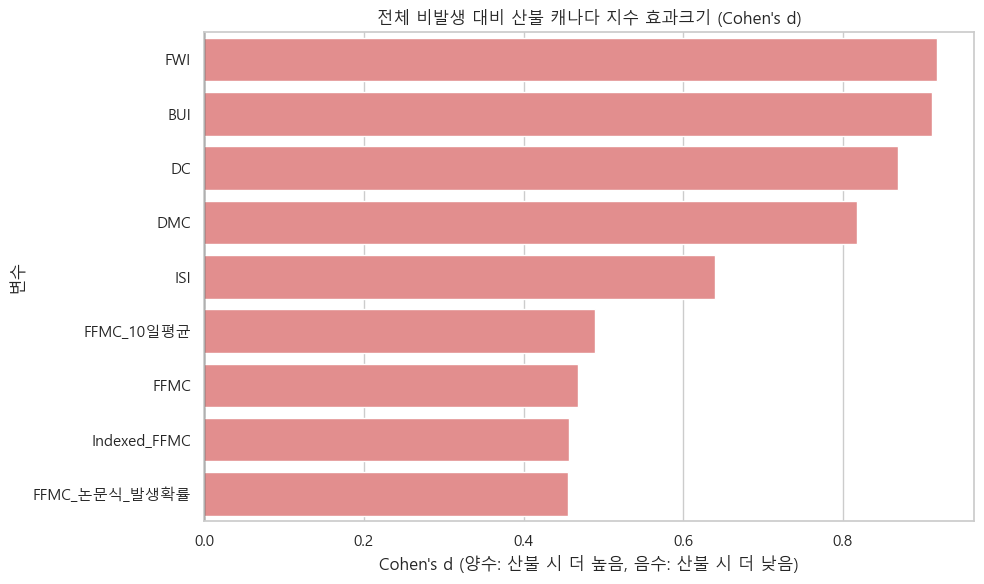

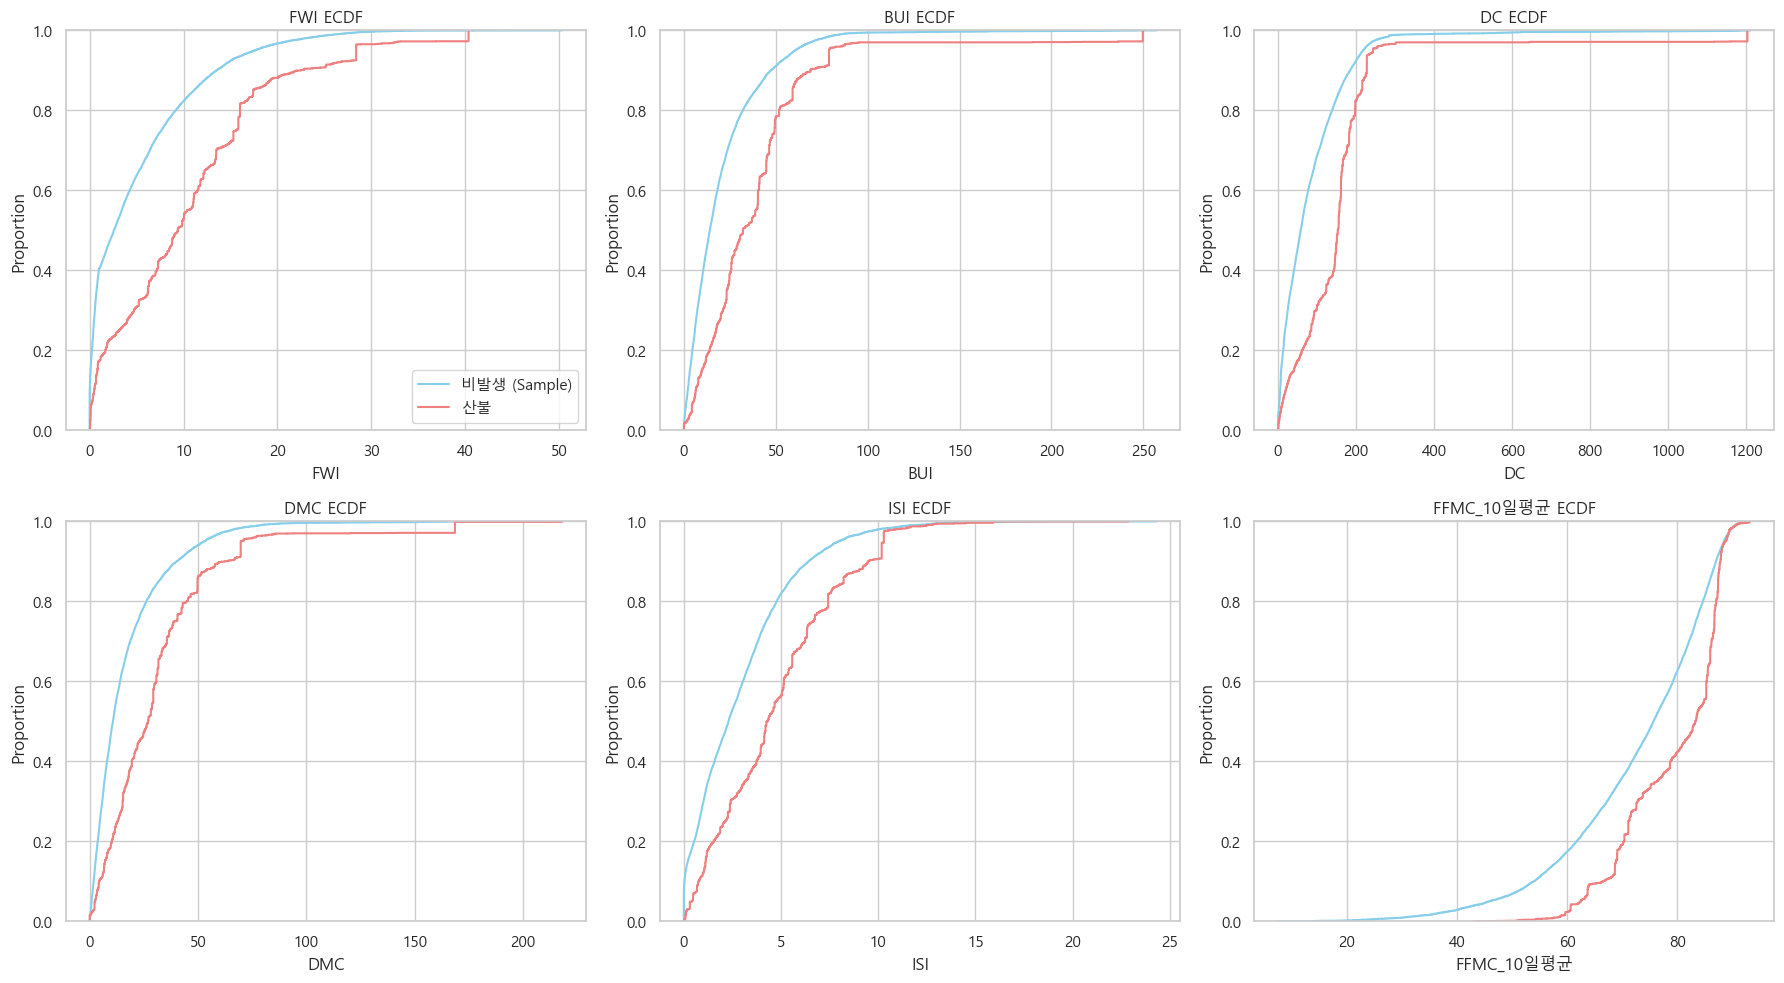

In [13]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from re_eda_common import load_fire, load_grid_bundle, load_hourly_weather, load_canadian_indices, add_canadian_asof_keys

# BH FDR function
def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    nan_mask = np.isnan(pvals)
    valid_pvals = pvals[~nan_mask]
    n = len(valid_pvals)
    if n == 0: return pvals
    sorted_idx = np.argsort(valid_pvals)
    sorted_pvals = valid_pvals[sorted_idx]
    qvals = np.zeros(n)
    qvals[sorted_idx] = sorted_pvals * n / np.arange(1, n + 1)
    for i in range(n - 2, -1, -1):
        qvals[sorted_idx[i]] = min(qvals[sorted_idx[i]], qvals[sorted_idx[i+1]])
    qvals = np.minimum(qvals, 1.0)
    res = np.full(len(pvals), np.nan)
    res[~nan_mask] = qvals
    return res

# 1. 데이터 로드
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_grid = grid_bundle["grid"]

fire_joined = gpd.sjoin(fire_points, weather_grid, how='left', predicate='within')
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched['기준시각'] = pd.to_datetime(fire_matched['기준시각'])
fire_events = set(zip(fire_matched['기상셀ID'], fire_matched['기준시각']))

print("Loading lightweight hourly weather keys...")
hourly_keys = load_hourly_weather(derived=False, columns=['기상셀ID', '일시'])

print("Loading Canadian indices...")
canada_idx = load_canadian_indices()
canada_idx = canada_idx[['기상셀ID', '날짜', 'FFMC', 'FFMC_10일평균', 'Indexed_FFMC', 'FFMC_논문식_발생확률', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']]

# 2. 캐나다 지수 결합용 날짜 키 생성
hourly_keys = add_canadian_asof_keys(hourly_keys, time_column='일시')
hourly_keys['캐나다지수_기준날짜'] = pd.to_datetime(hourly_keys['캐나다지수_기준날짜'])

# 3. 산불 군과 전체 비발생 군 분리
fire_keys = pd.DataFrame(list(fire_events), columns=['기상셀ID', '일시'])
fire_keys['is_fire'] = True
merged = hourly_keys.merge(fire_keys, on=['기상셀ID', '일시'], how='left')
non_fire_mask = merged['is_fire'].isna()

non_fire_keys = hourly_keys[non_fire_mask][['기상셀ID', '일시', '캐나다지수_기준날짜']].copy()
non_fire_keys = non_fire_keys.rename(columns={'캐나다지수_기준날짜': '날짜'})
non_fire_group = non_fire_keys.merge(canada_idx, on=['기상셀ID', '날짜'], how='inner')

fire_df = fire_matched[['fire_id', '기상셀ID', '기준시각']].rename(columns={'기준시각': '일시'})
fire_df = add_canadian_asof_keys(fire_df, time_column='일시')
fire_df['캐나다지수_기준날짜'] = pd.to_datetime(fire_df['캐나다지수_기준날짜'])
fire_df = fire_df.rename(columns={'캐나다지수_기준날짜': '날짜'})
fire_group = fire_df.merge(canada_idx, on=['기상셀ID', '날짜'], how='inner')

print(f"산불 군 크기: {len(fire_group):,}")
print(f"전체 비발생 군 크기: {len(non_fire_group):,}")

# 4. 분석 대상 변수
INDEX_VARS = ['FFMC', 'FFMC_10일평균', 'Indexed_FFMC', 'FFMC_논문식_발생확률', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']

# 5. 통계 검정 및 효과크기 계산
results = []
for var in INDEX_VARS:
    x_fire = fire_group[var].dropna()
    x_non = non_fire_group[var].dropna()
    if len(x_fire) == 0 or len(x_non) == 0: continue
    mean_fire, mean_non = x_fire.mean(), x_non.mean()
    t_stat, p_welch = stats.ttest_ind(x_fire, x_non, equal_var=False)
    u_stat, p_mw = stats.mannwhitneyu(x_fire, x_non, alternative='two-sided')
    n1, n2 = len(x_fire), len(x_non)
    var1, var2 = x_fire.var(ddof=1), x_non.var(ddof=1)
    pooled_se = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (mean_fire - mean_non) / pooled_se if pooled_se > 0 else np.nan
    results.append({'변수': var, '산불_Mean': mean_fire, '비발생_Mean': mean_non, 'Welch_p': p_welch, 'MW_p': p_mw, 'Cohen_d': d})

stats_df = pd.DataFrame(results)
stats_df['Welch_FDR'] = fdr_bh(stats_df['Welch_p'])
stats_df['MW_FDR'] = fdr_bh(stats_df['MW_p'])
stats_df['abs_d'] = stats_df['Cohen_d'].abs()
stats_df = stats_df.sort_values('abs_d', ascending=False).drop(columns=['abs_d'])
stats_df.to_csv("outputs/Step2/tables/S2-06_overall_comparison_canada_idx.csv", index=False, encoding='utf-8-sig')

print("\n상위 5개 변수 (효과크기 기준):")
print(stats_df.head(5)[['변수', 'Cohen_d', 'Welch_FDR', 'MW_FDR']])

# 6. 시각화
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
sns.barplot(data=stats_df, x='Cohen_d', y='변수', hue='변수', palette=np.where(stats_df['Cohen_d'] > 0, 'lightcoral', 'skyblue').tolist(), legend=False, ax=ax_bar)
ax_bar.set_title("전체 비발생 대비 산불 캐나다 지수 효과크기 (Cohen's d)")
ax_bar.set_xlabel("Cohen's d (양수: 산불 시 더 높음, 음수: 산불 시 더 낮음)")
ax_bar.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

top_vars = stats_df['변수'].head(6).tolist()
fig_ecdf, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
sample_non_fire = non_fire_group.sample(n=min(10000, len(non_fire_group)), random_state=42)
for i, var in enumerate(top_vars):
    if i >= 6: break
    sns.ecdfplot(data=sample_non_fire, x=var, ax=axes[i], color='skyblue', label='비발생 (Sample)')
    sns.ecdfplot(data=fire_group, x=var, ax=axes[i], color='lightcoral', label='산불')
    axes[i].set_title(f"{var} ECDF")
    if i == 0: axes[i].legend()
    else: axes[i].get_legend().remove() if axes[i].get_legend() else None
plt.tight_layout()
plt.show()